In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import csv
import re

In [196]:
# Read the .csv file
path = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\code\\keras-ns\\experiments\\countries\\hparamsearch\\experiments.csv"
df = pd.read_csv(path, sep=';')
df.head(5)

for column in df:
    try:
        # For all the colum, apply eval() to convert the string to a list
        df[column] = [np.array(eval(i)) for i in df[column].values]
        
    except:
        # print("Error in ", column)
        continue

# for each col that is a string or int or object, print the unique values 
for col in df.columns:
    try: 
        if df[col].dtype == 'object' or df[col].dtype == 'int64' or df[col].dtype == 'string':
            print(df[col].unique())
            print(col)
            print()
    except:
        continue

# results = df.loc[(df['Grounder'] == 'known') & (df['KGE'] == 'distmult') & (df['EmbedSize'] == 10)]
# results

['train_S1_p']
Task

['domainbody' 'backward' 'known' 'full' 'domain']
Grounder

['complex' 'distmult' 'transe']
KGE

[100]
EmbedSize

[1]
Reasoner_depth

['no_reasoner' 'dcr' 'r2n' 'sbr' 'rnm']
Model_name



In [197]:
def split_df(df):
    # create a df that is the same as the original but with the first value of the colums in the list metrics
    df_mean = df.copy()
    for col in df_mean.columns:
        try:
            df_mean[col] = [i[0] for i in df_mean[col].values]
        except:
            continue
    # Do the same for the std
    df_std = df.copy()
    for col in df_std.columns:
        try:
            df_std[col] = [i[1] for i in df_std[col].values]
        except:
            continue
    return df_mean, df_std

# Tables

One table for the different models with KGE complex (also for the other KGEs)
Another table for the different KGEs
Another table for the time with the best model and the best KGE

In [202]:
# Table 1: rows:grounder, cols:Model, values: mrr
csv_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\code\\keras-ns\\experiments\\countries\\hparamsearch\\results.csv"
cols = 'Grounder'
rows = 'Model_name'
metric = 'test_task_mrr'
baseline_model = 'no_reasoner'
baseline_metric = 'test_concept_mrr'
for metric in ['test_task_mrr', 'Time']:
    for KGE in ['complex', 'distmult', 'transe']:
        # filter the df
        results = df.loc[ (df['KGE'] == KGE) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
        # take only the columns grounder, model, test_task_mrr, test_concept_mrr
        results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
        # put the model_name as colums
        results = results.pivot(index=rows, columns=cols, values=metric)
        if metric == 'test_task_mrr':
            # in the column no_reasoner, put the values of the column test_concept_mrr
            substitute = df.loc[ (df['KGE'] == 'complex') & (df['Model_name'] == baseline_model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)][[cols,rows,baseline_metric]]
            substitute = substitute.pivot(index=rows, columns=cols, values=baseline_metric)
            # substitute the values in the table
            results.loc[baseline_model] = substitute.loc[baseline_model] 

        print(results) 
        with open(csv_dir, 'a') as f:
            f.write('\n KGE : ,' + KGE + ', Metric: ,' + metric)
            f.write('\n ')
        results.to_csv(csv_dir, mode='a', header=True)  

Grounder             backward            domain        domainbody  \
Model_name                                                          
dcr           [0.9206, 0.011]  [0.9221, 0.0144]   [0.917, 0.0112]   
no_reasoner  [0.9215, 0.0099]  [0.9215, 0.0099]  [0.9215, 0.0099]   
r2n          [0.9224, 0.0153]  [0.9281, 0.0044]  [0.9247, 0.0097]   
rnm          [0.9317, 0.0138]   [0.937, 0.0068]  [0.9317, 0.0092]   
sbr          [0.9617, 0.0184]  [0.9567, 0.0202]  [0.9611, 0.0219]   

Grounder                 full             known  
Model_name                                       
dcr          [0.9199, 0.0116]  [0.9424, 0.0272]  
no_reasoner  [0.9215, 0.0099]  [0.9215, 0.0099]  
r2n          [0.9281, 0.0044]    [0.994, 0.008]  
rnm           [0.937, 0.0068]  [0.9263, 0.0099]  
sbr          [0.9567, 0.0202]   [0.959, 0.0212]  
Grounder             backward            domain        domainbody  \
Model_name                                                          
dcr          [0.9141, 0.0047

In [203]:
# Table 1: rows:grounder, cols:Model, values: mrr
csv_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\code\\keras-ns\\experiments\\countries\\hparamsearch\\results.csv"
cols = 'Grounder'
rows = 'KGE'
metrics = ['test_task_mrr','Time']
for metric in metrics:
    for model in df['Model_name'].unique():
        # filter the df
        results = df.loc[ (df['Model_name'] == model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
        # take only the columns grounder, model, test_task_mrr, test_concept_mrr
        results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
        # put the model_name as colums
        results = results.pivot(index=rows, columns=cols, values=metric)
        print(results)
        with open(csv_dir, 'a') as f:
            f.write('\nModel : ,' + model + ', Metric: ,' + metric)
            f.write('\n ')
        results.to_csv(csv_dir, mode='a', header=True)  

Grounder          backward            domain        domainbody  \
KGE                                                              
complex   [0.7321, 0.0418]  [0.7321, 0.0418]  [0.7321, 0.0418]   
distmult  [0.7321, 0.0418]  [0.7321, 0.0418]  [0.7321, 0.0418]   
transe    [0.7321, 0.0418]  [0.7321, 0.0418]  [0.7321, 0.0418]   

Grounder              full             known  
KGE                                           
complex   [0.7321, 0.0418]  [0.7321, 0.0418]  
distmult  [0.7321, 0.0418]  [0.7321, 0.0418]  
transe    [0.7321, 0.0418]  [0.7321, 0.0418]  
Grounder          backward            domain        domainbody  \
KGE                                                              
complex    [0.9206, 0.011]  [0.9221, 0.0144]   [0.917, 0.0112]   
distmult  [0.9141, 0.0047]  [0.9034, 0.0075]   [0.913, 0.0048]   
transe    [0.8041, 0.0177]  [0.7585, 0.0595]  [0.7674, 0.0581]   

Grounder              full             known  
KGE                                           
complex  

# PLOTS

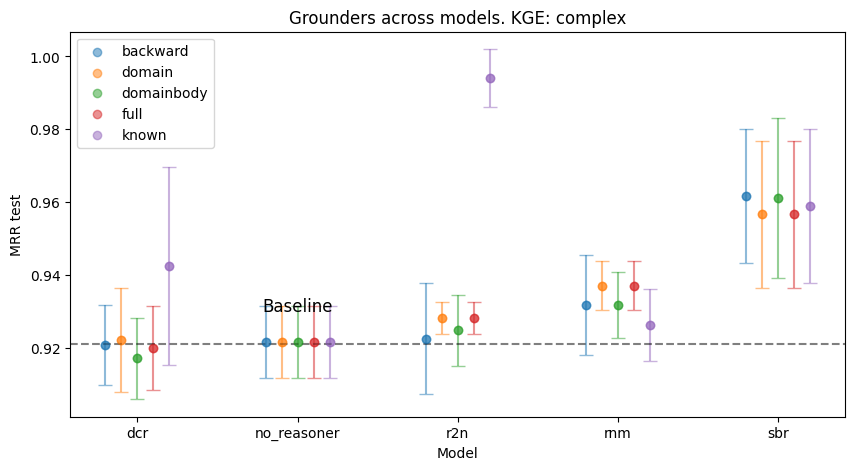

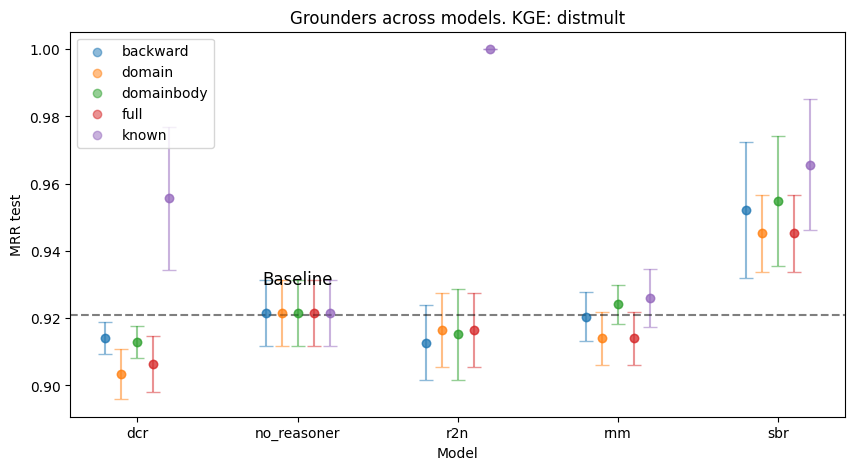

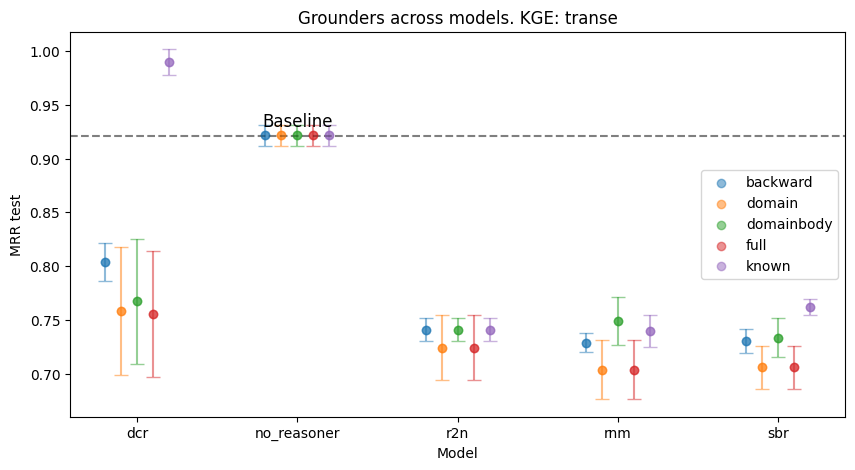

In [217]:
# Table 1: rows:grounder, cols:Model, values: mrr
root_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\code\\keras-ns\\experiments\\countries\\hparamsearch\\"
cols = 'Grounder'
rows = 'Model_name'
metric = 'test_task_mrr'
baseline_model = 'no_reasoner'
baseline_metric = 'test_concept_mrr'
for KGE in ['complex', 'distmult', 'transe']:
    # filter the df
    results = df.loc[ (df['KGE'] == KGE) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
    # take only the columns grounder, model, test_task_mrr, test_concept_mrr
    results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
    # put the model_name as colums
    results = results.pivot(index=rows, columns=cols, values=metric)

    # in the column no_reasoner, put the values of the column test_concept_mrr
    substitute = df.loc[ (df['KGE'] == 'complex') & (df['Model_name'] == baseline_model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)][[cols,rows,baseline_metric]]
    substitute = substitute.pivot(index=rows, columns=cols, values=baseline_metric)
    # substitute the values in the table
    results.loc[baseline_model] = substitute.loc[baseline_model]
    results
    df_mean, df_std = split_df(results)

    # Remove no reasoner and include a line where it is written baseline
    plt.figure(figsize=(10,5))
    for i,grounder in enumerate(df_mean.columns):
        plt.scatter(np.arange(len(df_mean.index))+0.1*i, df_mean[grounder], label=grounder, alpha=0.5)
        plt.errorbar(np.arange(len(df_mean.index))+0.1*i, df_mean[grounder], yerr=df_std[grounder], fmt='o',capsize=5, alpha=0.5)
    plt.axhline(y=0.921, color='black', linestyle='--', alpha=.5)  # Change color and linestyle as desired
    plt.text(1.2, 0.93, 'Baseline', color='black', fontsize=12, ha='center')
    plt.legend()
    plt.xticks(np.arange(len(df_mean.index))+0.2, df_mean.index.tolist(), rotation=0)
    plt.ylabel('MRR test')
    plt.xlabel('Model')
    plt.title(f'Grounders across models. KGE: {KGE}')
    # plt.show()
    # SAVE THE FIGURE
    plt.savefig(root_dir+'figures\\Grounders_across_models___KGE_'+KGE+'.png', dpi=300, bbox_inches='tight')  

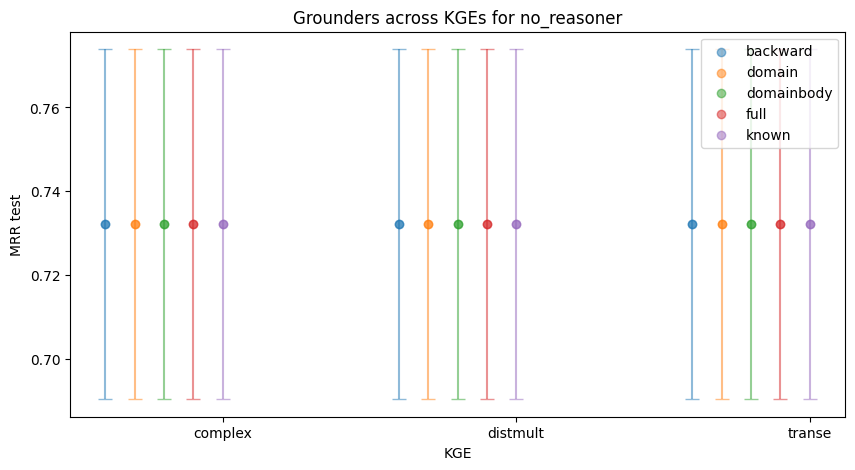

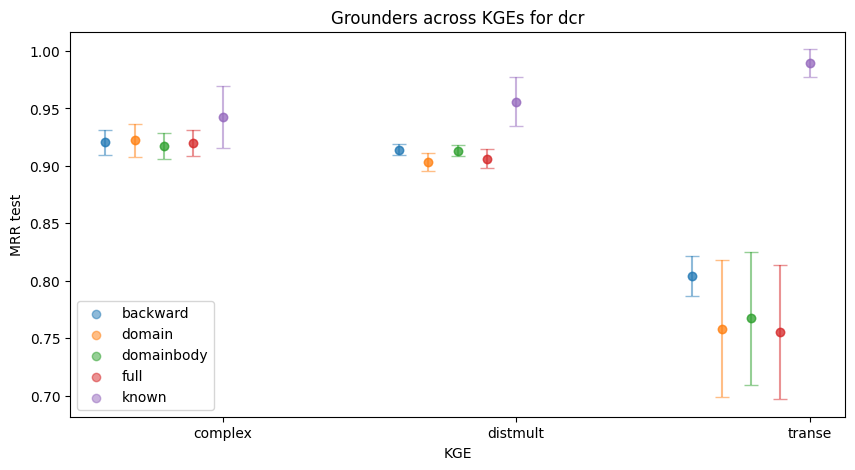

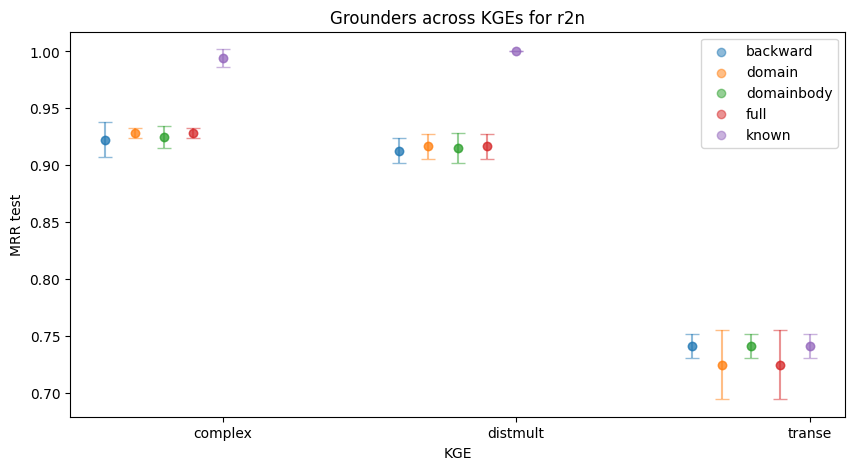

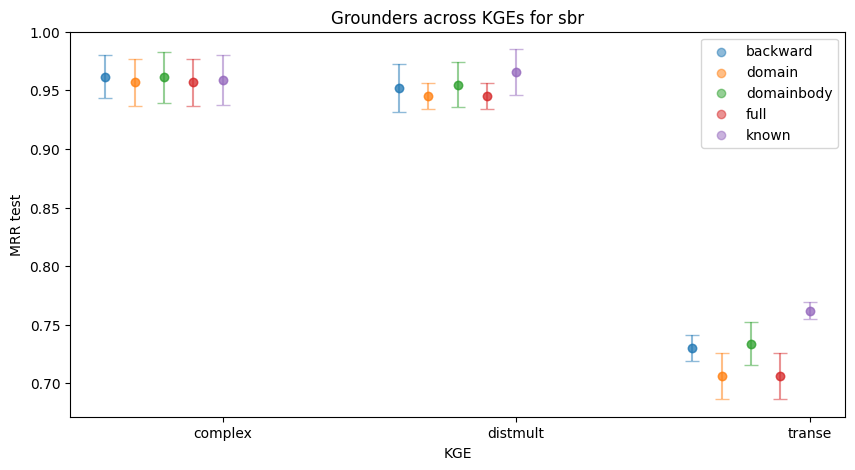

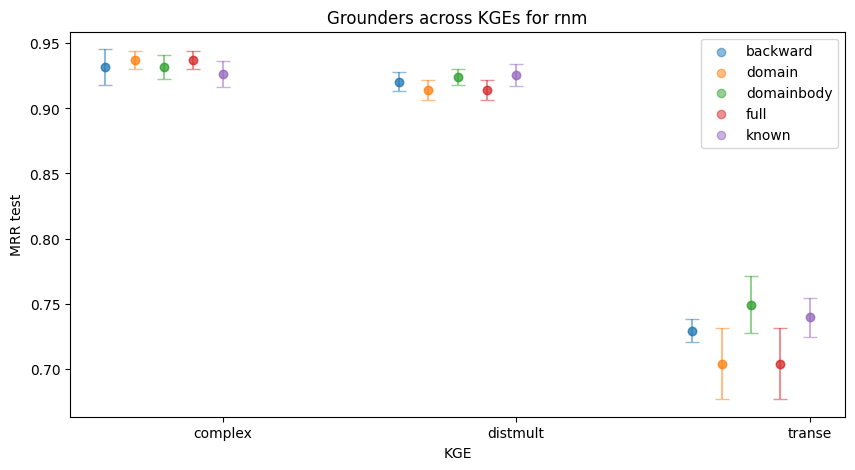

In [218]:
# Table2: rows:grounder, cols:kge, values: mrr
model = 'dcr'
for model in df['Model_name'].unique():
    cols = 'Grounder'
    rows = 'KGE'
    metric = 'test_task_mrr'
    baseline_model = 'no_reasoner'
    baseline_metric = 'test_concept_mrr'
    # filter the df
    results = df.loc[ (df['Model_name'] == model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
    # take only the columns grounder, model, test_task_mrr, test_concept_mrr
    results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
    # put the model_name as colums
    results = results.pivot(index=rows, columns=cols, values=metric)

    # # in the column no_reasoner, put the values of the column test_concept_mrr
    # substitute = df.loc[ (df['KGE'] == 'complex') & (df['Model_name'] == baseline_model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)][[cols,rows,baseline_metric]]
    # substitute = substitute.pivot(index=rows, columns=cols, values=baseline_metric)
    # # substitute the values in the table
    # results.loc[baseline_model] = substitute.loc[baseline_model]


    df_mean, df_std = split_df(results)
    # Remove no reasoner and include a line where it is written baseline
    plt.figure(figsize=(10,5))
    for i,grounder in enumerate(df_mean.columns):
        plt.scatter(np.arange(len(df_mean.index))+0.1*i, df_mean[grounder], label=grounder, alpha=0.5)
        plt.errorbar(np.arange(len(df_mean.index))+0.1*i, df_mean[grounder], yerr=df_std[grounder], fmt='o',capsize=5, alpha=0.5)
    plt.legend()
    plt.xticks(np.arange(len(df_mean.index))+0.1*i, df_mean.index.tolist(), rotation=0)
    plt.ylabel('MRR test')
    plt.xlabel('KGE')
    plt.title(f'Grounders across KGEs for {model}')
    # plt.show()
    plt.savefig(root_dir+'figures\\Grounders_across_KGE___Model_'+model+'.png', dpi=300, bbox_inches='tight')  